In [5]:
import pandas as pd
import os
import matplotlib.pyplot as plt
from scipy import stats

col = 'mutation_coverage'

pitest_figures_out = '../../generated/figures/pitest'
pitest_data_path = '../../generated/code-analysis/pitest.csv'

if not os.path.exists(pitest_data_path):
    raise FileNotFoundError(f"Le fichier {pitest_data_path} n'existe pas. Exécutez d'abord le notebook '../arrange data/Pitest.ipynb' avant.")

df_pitest = pd.read_csv(pitest_data_path)

# Boxplot

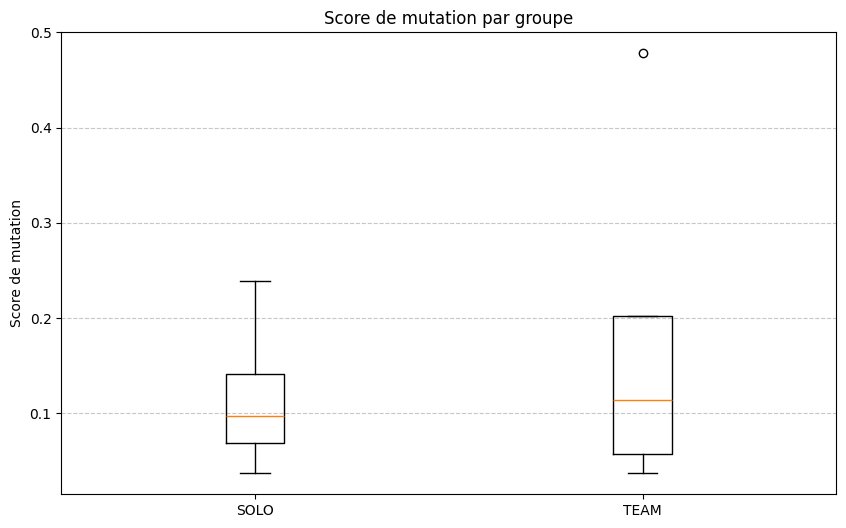

In [6]:
if not os.path.exists(pitest_figures_out):
    os.makedirs(pitest_figures_out)

plt.figure(figsize=(10, 6))
plt.boxplot([
    df_pitest[(df_pitest['game_mode'] == 'SOLO')][col],
    df_pitest[(df_pitest['game_mode'] == 'TEAM')][col]
], tick_labels=['SOLO', 'TEAM'])

plt.title('Score de mutation par groupe')
plt.ylabel('Score de mutation')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig(f"{pitest_figures_out}/mutation_score_by_game_mode.pdf")
plt.show()

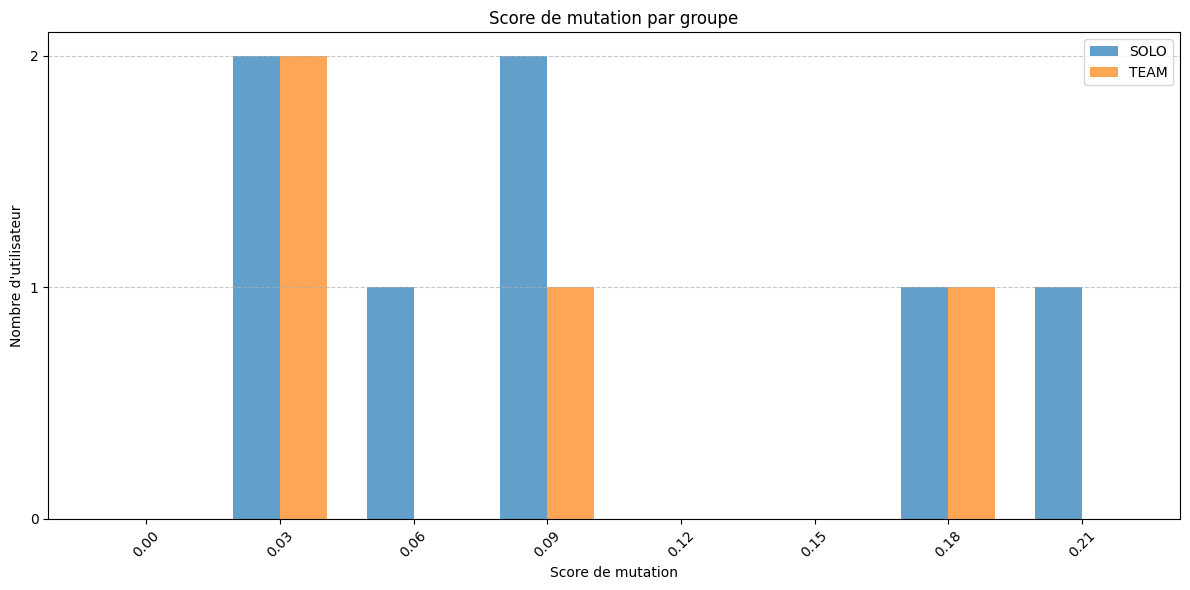

In [16]:
import numpy as np

solo_data = df_pitest[df_pitest['game_mode'] == 'SOLO'][col].dropna()
team_data = df_pitest[df_pitest['game_mode'] == 'TEAM'][col].dropna()

bins = np.arange(0.0, 0.25, 0.03) 

solo_counts, _ = np.histogram(solo_data, bins=bins)
team_counts, _ = np.histogram(team_data, bins=bins)

x = np.arange(len(bins) - 1)
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width/2, solo_counts, width, label='SOLO', alpha=0.7)
ax.bar(x + width/2, team_counts, width, label='TEAM', alpha=0.7)

ax.set_xticks(x)
ax.set_xticklabels([f"{b:.2f}" for b in bins[:-1]], rotation=45)
ax.set_xlabel('Score de mutation')
ax.set_ylabel('Nombre d\'utilisateur')
ax.set_title('Score de mutation par groupe')
ax.legend()
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))  # integer y-axis
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(f"{pitest_figures_out}/mutation_score_by_game_mode_barplot.pdf")
plt.show()

In [8]:
solo_mean = solo_data.mean()
team_mean = team_data.mean()
print(f"SOLO mean: {solo_mean:.4f}, TEAM mean: {team_mean:.4f}")
team_mean_without_outliers = team_data[team_data < 0.3].mean()
print(f"TEAM mean without outliers: {team_mean_without_outliers:.4f}")

SOLO mean: 0.1135, TEAM mean: 0.1778
TEAM mean without outliers: 0.1027
